In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scanpy as sc

import os

import scvi


def order_m(m):
    n = min(*m.shape)
    
    ordered_cols = []
    remain_cols = list(range(m.shape[1]))
    
    for i in range(n):
        ic = m[i, remain_cols].argmax()
        c = remain_cols[ic]
        ordered_cols.append(c)
        remain_cols.remove(c)
    
    return ordered_cols, remain_cols



canonical_markers = ["IL32", "LTB", "CD3D",
    "IL7R", "LDHB", "FCGR3A", 
    "CD68", "MS4A1", "GNLY", 
    "CD3E", "CD14", "CD14", 
    "FCGR3A", "LYZ", "PPBP", 
    "CD8A", "PPBP", "CST3", 
    "NKG7", "MS4A7", "MS4A1", 
    "CD8A", "CD4", "NCAM1"]

    

In [2]:
## Downloaded CR-arc count matrix results
data_dir = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/downloaded_counts/VIB_10xmultiome_2'

h5_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2-outs-raw_feature_bc_matrix-matrix.h5ad')

barcodes_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.barcodes.tsv')

features_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.features.tsv')

h5 = sc.read_h5ad(h5_file)

features_pd = pd.read_csv(features_file, header=None, sep='\t')

barcodes_pd = pd.read_csv(barcodes_file, header=None, sep='\t')

## It's feature -by- barcode matrix, need to transpose
h5.var = barcodes_pd
h5.obs = features_pd 
h5.obs.columns = ['feature_id', 'name', 'feature_type', 'chrom', 'start', 'end']
h5.var.columns = ['barcodes']


## Entropy filtered atac
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_downstream_dir = os.path.join(entropy_dir, 'DownstreamReanalysis')
entropy_peak_file = os.path.join(entropy_downstream_dir, 'entropy_peakvi.h5ad')
peak_file = os.path.join(entropy_downstream_dir, 'peakvi.h5ad')

entropy_peak = sc.read_h5ad(entropy_peak_file)
peak = sc.read_h5ad(peak_file)

# atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')


In [3]:
entropy_peak, peak, h5, features_pd.shape, barcodes_pd.shape, bc_map_pd.shape

(AnnData object with n_obs × n_vars = 2125 × 36729
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 2125 × 31116
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 104068 × 687495
     obs: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end'
     var: 'barcodes',
 (104068, 6),
 (687495, 1),
 (736320, 2))

## plot atac clustering results

In [4]:
# atac clsutering at different resolutions
atac_resolution = 0.5
sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_entropy', resolution=atac_resolution)
sc.tl.leiden(peak, key_added='clusters_peakvi_all', resolution=atac_resolution)

/tmp/ipykernel_4095703/74531020.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_entropy', resolution=atac_resolution)


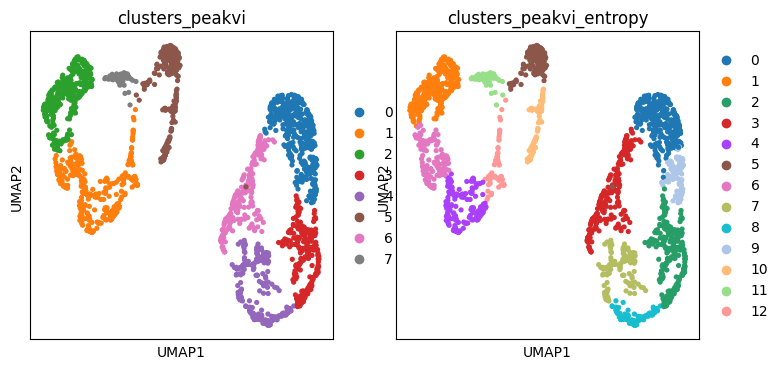

In [8]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(entropy_peak, color=['clusters_peakvi', 'clusters_peakvi_entropy'], wspace=0.1)

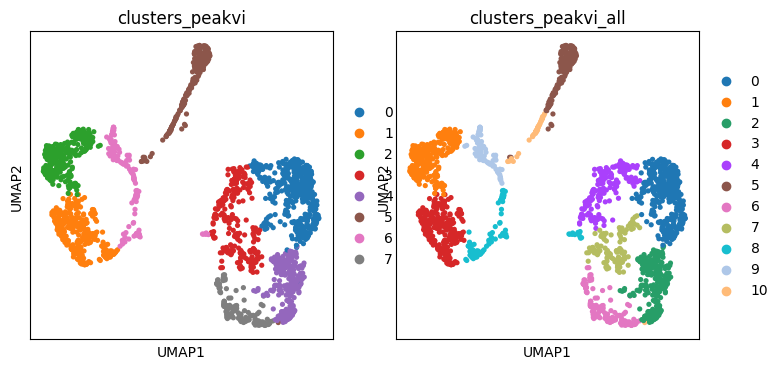

In [7]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(peak, color=['clusters_peakvi', 'clusters_peakvi_all'], wspace=0.1)

In [9]:
entropy_peak.obs['clusters_peakvi_r_entropy'] = entropy_peak.obs['clusters_peakvi']  # Add suffix for name
peak.obs['clusters_peakvi_r_all'] = peak.obs['clusters_peakvi']

In [10]:
entropy_peak_df = entropy_peak.obs.copy()
entropy_peak_df.set_index('barcodes', inplace=True)

peak_df = peak.obs.copy()
peak_df.set_index('barcodes', inplace=True)

peak_df.join(entropy_peak_df['clusters_peakvi_entropy']).groupby(['clusters_peakvi_all', 'clusters_peakvi_entropy']).size().unstack(fill_value=0)


/tmp/ipykernel_4095703/1058780932.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  peak_df.join(entropy_peak_df['clusters_peakvi_entropy']).groupby(['clusters_peakvi_all', 'clusters_peakvi_entropy']).size().unstack(fill_value=0)


clusters_peakvi_entropy,0,1,2,3,4,5,6,7,8,9,10,11,12
clusters_peakvi_all,,,,,,,,,,,,,
0,306,0,3,13,0,0,0,0,0,76,0,1,0
1,0,278,0,0,0,0,18,0,0,0,1,2,0
2,0,0,243,0,0,1,0,4,2,13,0,1,0
3,0,8,0,0,126,0,124,0,0,0,2,0,0
4,10,0,0,178,0,0,0,1,0,0,0,0,0
5,0,0,0,1,0,141,0,0,0,0,40,1,0
6,0,0,12,0,0,0,0,31,108,0,0,0,0
7,1,0,2,20,0,0,0,99,0,4,0,0,0
8,0,0,0,7,47,0,0,0,0,0,0,1,55


## Matching atac bc with RNA bc

In [11]:
bc_map = bc_map_pd.set_index('atac_barcodes')

entropy_peak.obs['atac_bc'] =  entropy_peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
entropy_peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in entropy_peak.obs.columns:
    entropy_peak.obs = entropy_peak.obs.join(bc_map, how='inner')


peak.obs['atac_bc'] =  peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in peak.obs.columns:
    peak.obs = peak.obs.join(bc_map, how='inner')


bc_passed_entropy_df = entropy_peak.obs[['rna_barcodes']]

## RNA clustering

In [ ]:
# prepare for rna-bc correspondence to atac entropy filtered barcodes
entropy_passed_bc_map=bc_passed_entropy_df.reset_index(inplace=False)
entropy_passed_bc_map.set_index('rna_barcodes', inplace=True)
entropy_passed_bc_map.columns = ['atac_bc']


h5_rna_ = h5.transpose()
h5_rna_.obs['rna_barcodes'] = h5_rna_.obs['barcodes'].map(lambda x: x.split('-1')[0])
h5_rna_.obs.set_index('rna_barcodes', inplace=True)


# select gene expression only, and only the barcodes that passed entropy filtering
h5_rna_ = h5_rna_[:, h5_rna_.var['feature_type'] == 'Gene Expression']
h5_rna_ = h5_rna_[h5_rna_.obs.index.isin(entropy_passed_bc_map.index), :]
h5_rna_.obs = h5_rna_.obs.join(entropy_passed_bc_map, how='inner')

# calculate total RNA QC metrics
h5_rna_.obs['total_RNA_UMI'] = h5_rna_.X.sum(axis=1)
h5_rna_.obs['total_RNA_UMI_log'] = np.log1p(h5_rna_.obs['total_RNA_UMI'])
h5_rna_.obs['n_genes_by_RNA_counts'] = (h5_rna_.X > 0).sum(axis=1)
h5_rna_.obs['N_MT_counts'] = h5_rna_.X[:, h5_rna_.var.name.apply(lambda x: x.startswith('MT-'))].sum(axis=1)
h5_rna_.obs['MT%'] = h5_rna_.obs['N_MT_counts'] / h5_rna_.obs['total_RNA_UMI'] * 100

X_10k = sc.pp.normalize_total(h5_rna_, target_sum=1e4, inplace=False)['X']
h5_rna_.layers['log1p_counts'] = np.log1p(X_10k.copy())

h5_rna = h5_rna_[:, ~h5_rna_.var.name.apply(lambda x: x.startswith('MT-'))].copy() # Remove MT genes

# Add gene_name column 
h5_rna.var['gene_name'] = h5_rna.var['name'].astype(str)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


In [124]:
h5_rna_, h5_rna

(AnnData object with n_obs × n_vars = 2125 × 36601
     obs: 'barcodes', 'atac_bc', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end'
     layers: 'log1p_counts',
 AnnData object with n_obs × n_vars = 2125 × 36588
     obs: 'barcodes', 'atac_bc', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end'
     layers: 'log1p_counts')

In [125]:
sc.pp.filter_genes(h5_rna, min_counts=3)
h5_rna.raw = h5_rna # keep full dimension safe
h5_rna.layers['counts'] = h5_rna.X
sc.pp.highly_variable_genes(
h5_rna,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

In [ ]:
scvi.settings.seed = 0
scvi.model.SCVI.setup_anndata(h5_rna, layer="counts")
vae = scvi.model.SCVI(h5_rna, n_layers=3, n_latent=30, gene_likelihood="nb")
vae.train()
h5_rna.obsm["RNA_scVI"] = vae.get_latent_representation()


sc.pp.neighbors(h5_rna, use_rep='RNA_scVI')
sc.tl.umap(h5_rna, min_dist=0.3)

# print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
# vae_model_folder=os.path.join(args.o[0], "integrated_scvi_model")
# vae.save(vae_model_folder)

Seed set to 0
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/_scvi.py:168: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 

Epoch 400/400: 100%|██████████| 400/400 [01:29<00:00,  4.45it/s, v_num=1, train_loss_step=5.12e+3, train_loss_epoch=5.22e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [01:29<00:00,  4.45it/s, v_num=1, train_loss_step=5.12e+3, train_loss_epoch=5.22e+3]


In [157]:
# clustering using scVI latent representation via Leiden
sc.tl.leiden(h5_rna, key_added="leiden_RNA_scVI", resolution=atac_resolution + 0.1)

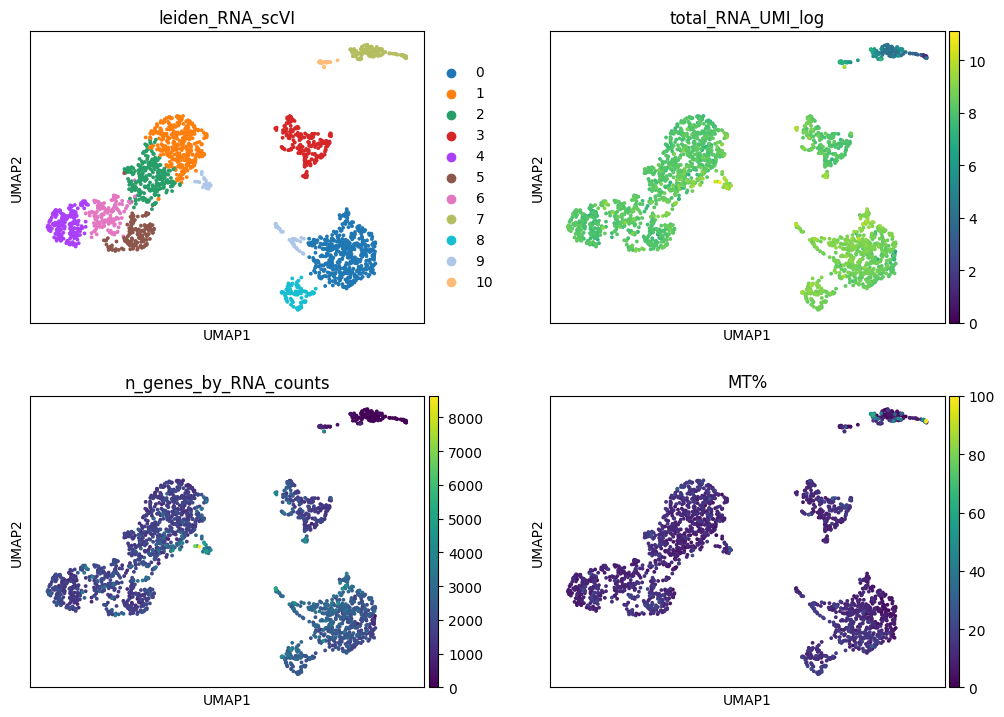

In [158]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'MT%'], wspace=0.2, size=30, ncols=2)

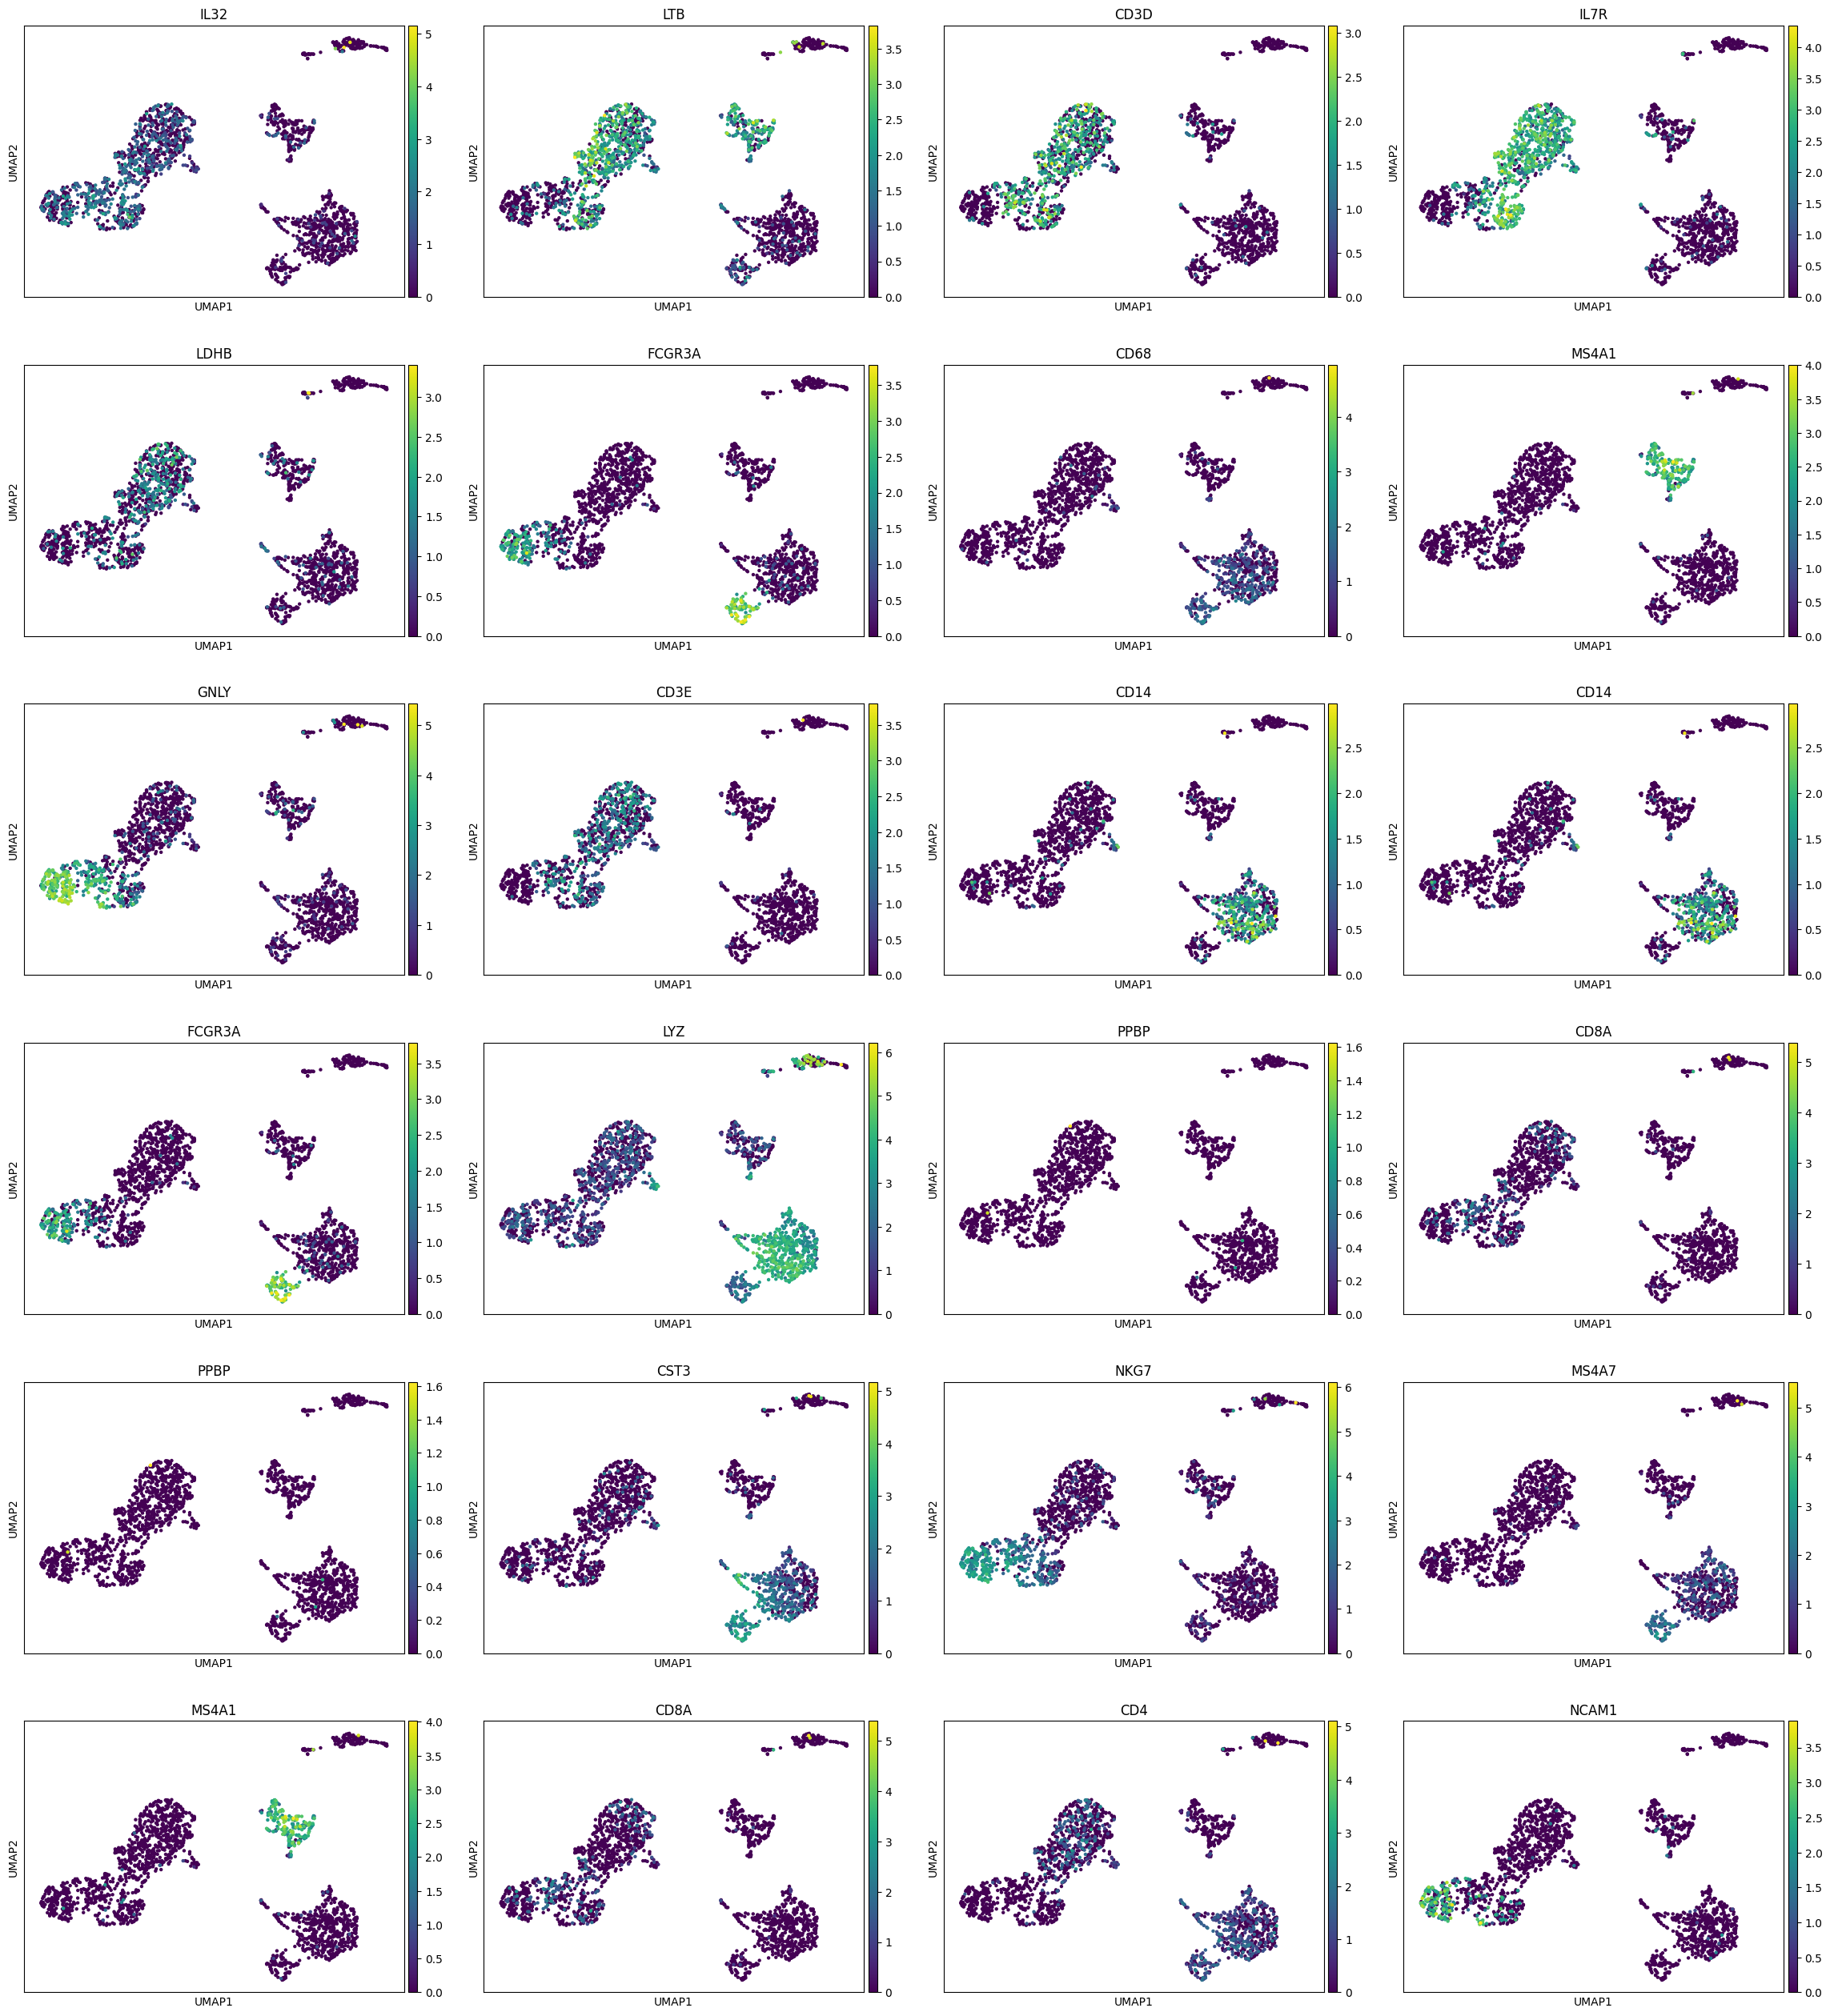

In [ ]:

canonical_markers_avail = [g for g in canonical_markers if g in h5_rna.var['gene_name'].values ]


# with plt.rc_context({'figure.figsize': (5, 5)}):
sc.pl.umap(h5_rna, color=canonical_markers_avail, wspace=0.1, ncols=4, size=40, gene_symbols='gene_name', layer='log1p_counts')

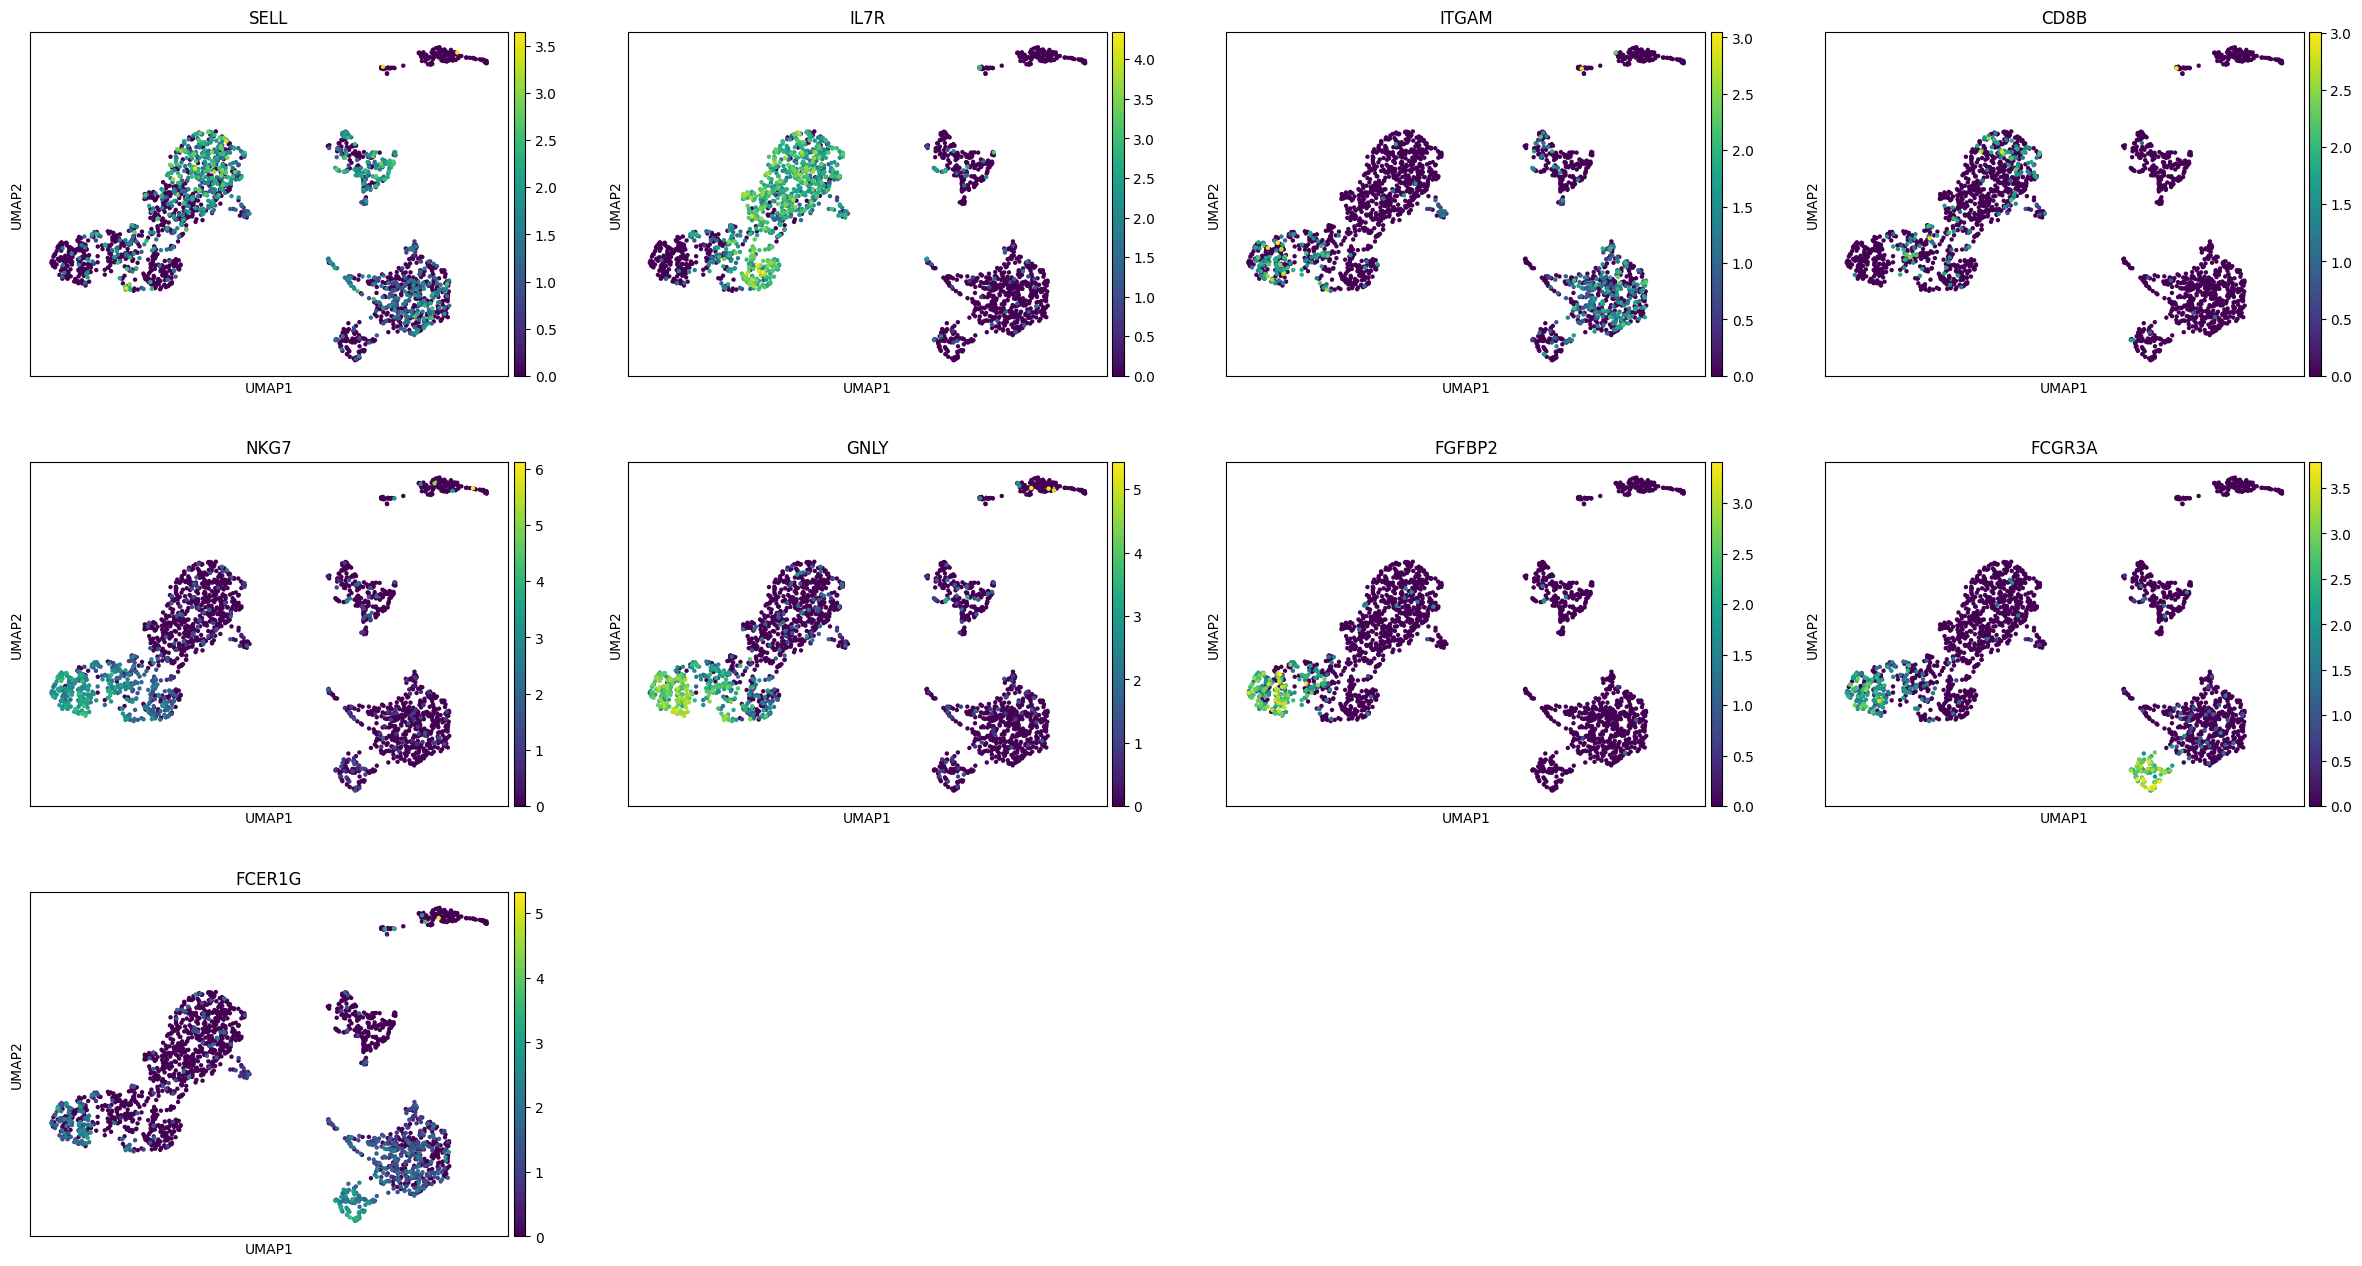

In [ ]:
sc.pl.umap(h5_rna, color=['SELL', 'IL7R', 'ITGAM'], size=40 , gene_symbols='gene_name', layer='log1p_counts')
# CD127 protein : gene IL7R (T cells subtype)
# CD62L protein : gene SELL (T cells subtype)
# CD11B protein: ITGAM gene: T cells do not express ITGAM (myloid)

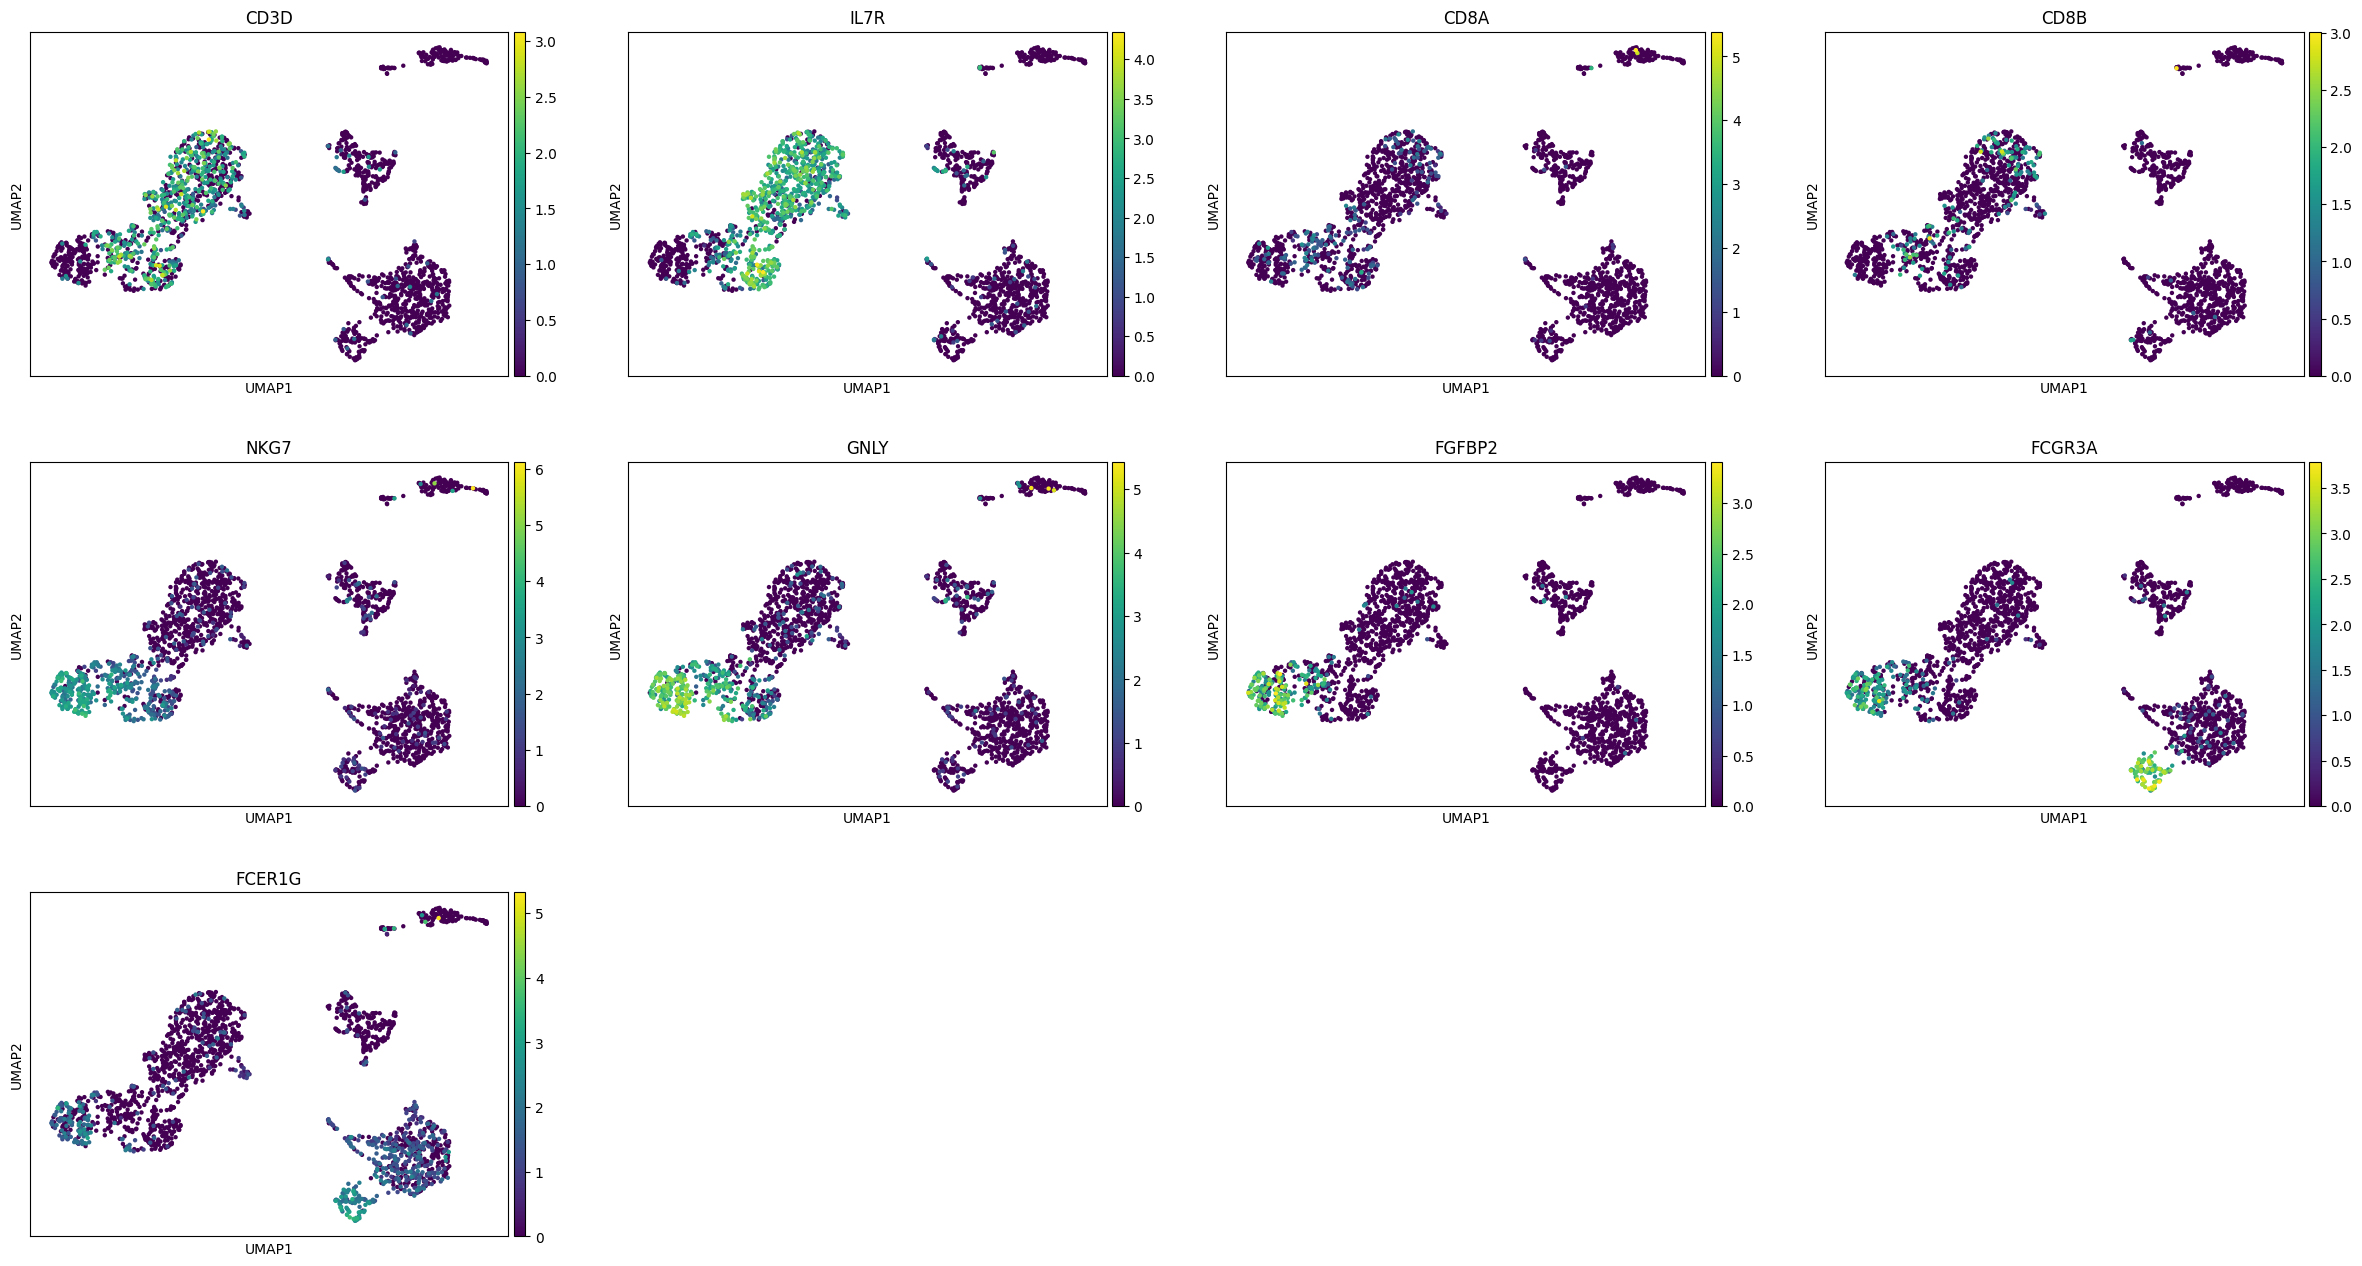

In [235]:
sc.pl.umap(h5_rna, color=['CD3D', 'IL7R', 'CD8A', 'CD8B',  'NKG7', 'GNLY', 'FGFBP2', 'FCGR3A', 'FCER1G'], size=40 , gene_symbols='gene_name', layer='log1p_counts')

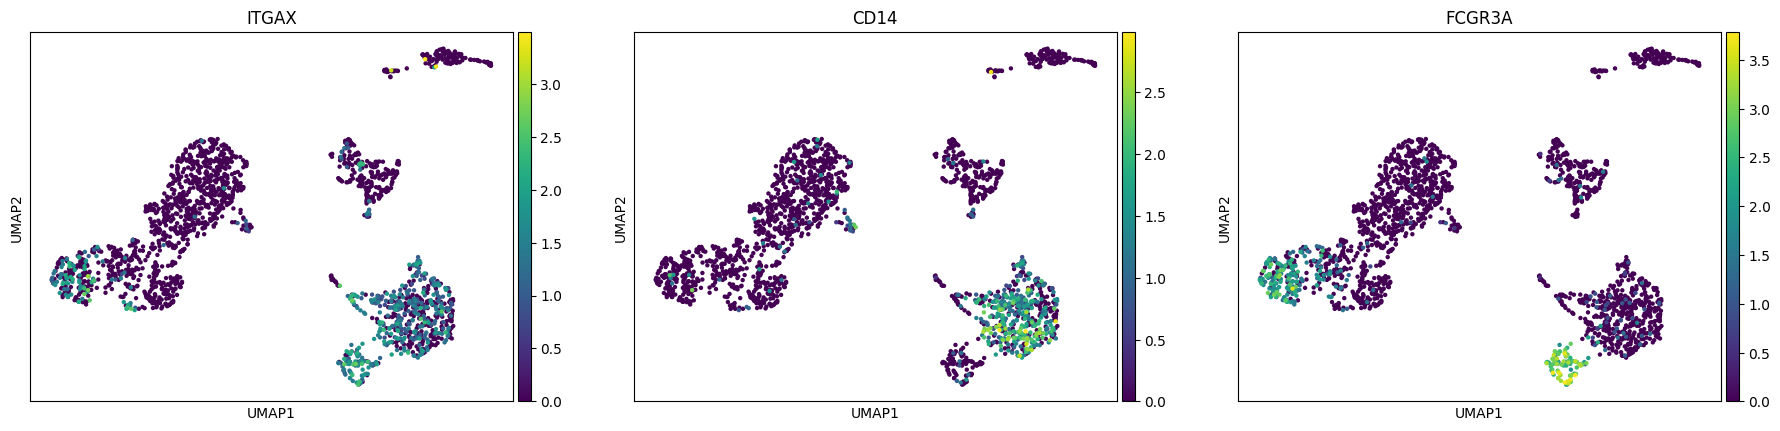

In [222]:
sc.pl.umap(h5_rna, color=[ 'ITGAX',   'CD14','FCGR3A' ], size=40 , gene_symbols='gene_name', layer='log1p_counts')
# CD11c protein: gene ITGAX -- DC 
# CD16 protein: gene FCGR3A -- NC monocytes

In [ ]:
cluster_average_df = pd.DataFrame(index=h5_rna.var['gene_name'])

for c in h5_rna.obs['leiden_RNA_scVI'].unique():
    a = h5_rna[h5_rna.obs['leiden_RNA_scVI'] == c, :].layers['log1p_counts'].mean(axis=0)
    cluster_average_df[c] = np.asarray(a).flatten()
    
cluster_average_df.to_csv('HiJuliana_check_pbmc_rna_cluster_average_normalized_expression.csv')

In [232]:
cluster_average_df.head()

,1,5,2,4,3,0,9,6,8,7,10
gene_name,,,,,,,,,,,
AL627309.1,0.006656,0.025596,0.000000,0.000000,0.000000,0.019356,0.012486,0.000000,0.018050,0.0,0.000000
AL627309.5,0.018019,0.000000,0.006604,0.016920,0.024014,0.083153,0.059519,0.000000,0.093862,0.0,0.000000
AL627309.4,0.000000,0.006008,0.000000,0.000000,0.000000,0.026590,0.002385,0.000000,0.021731,0.0,0.000000
AL669831.2,0.009073,0.000000,0.004487,0.000000,0.013659,0.000000,0.000000,0.010163,0.000000,0.0,0.000000
LINC01409,0.108814,0.134437,0.126373,0.127406,0.143420,0.167022,0.167751,0.099665,0.106097,0.0,0.053154


## Plot to see consistency between atac space and rna space 

In [160]:
if 'clusters_peakvi_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_entropy', axis=1, inplace=True)
if 'clusters_peakvi_r_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_r_entropy', axis=1, inplace=True)

if 'clusters_peakvi_all' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_all', axis=1, inplace=True)
if 'clusters_peakvi_r_all' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_r_all', axis=1, inplace=True)
    

h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[['clusters_peakvi_entropy', 'clusters_peakvi_r_entropy']], left_on='atac_bc', right_index=True, how='left')
# h5_rna.obs.rename(columns={'clusters_peakvi':'clusters_peakvi_entropy'}, inplace=True)
h5_rna.obs = h5_rna.obs.merge(peak.obs[['clusters_peakvi_all', 'clusters_peakvi_r_all']], left_on='atac_bc', right_index=True, how='left')

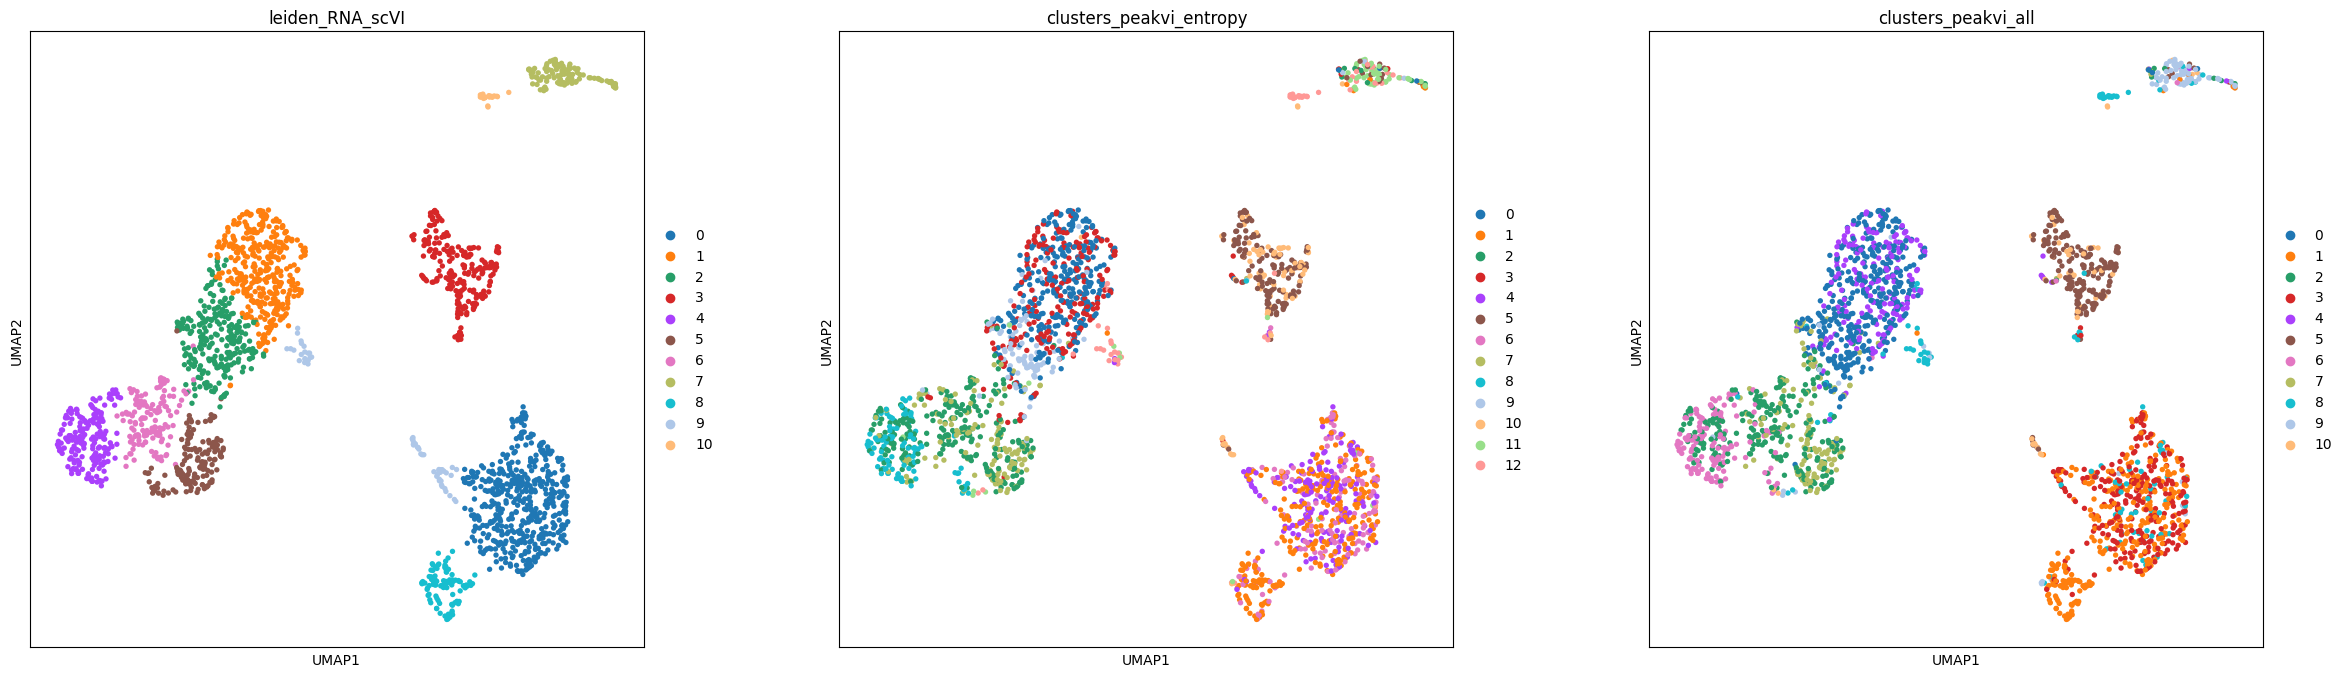

In [161]:
with plt.rc_context({'figure.figsize': (8, 8)}):
    sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'clusters_peakvi_entropy', 'clusters_peakvi_all'], wspace=0.2, ncols=3, size=60)

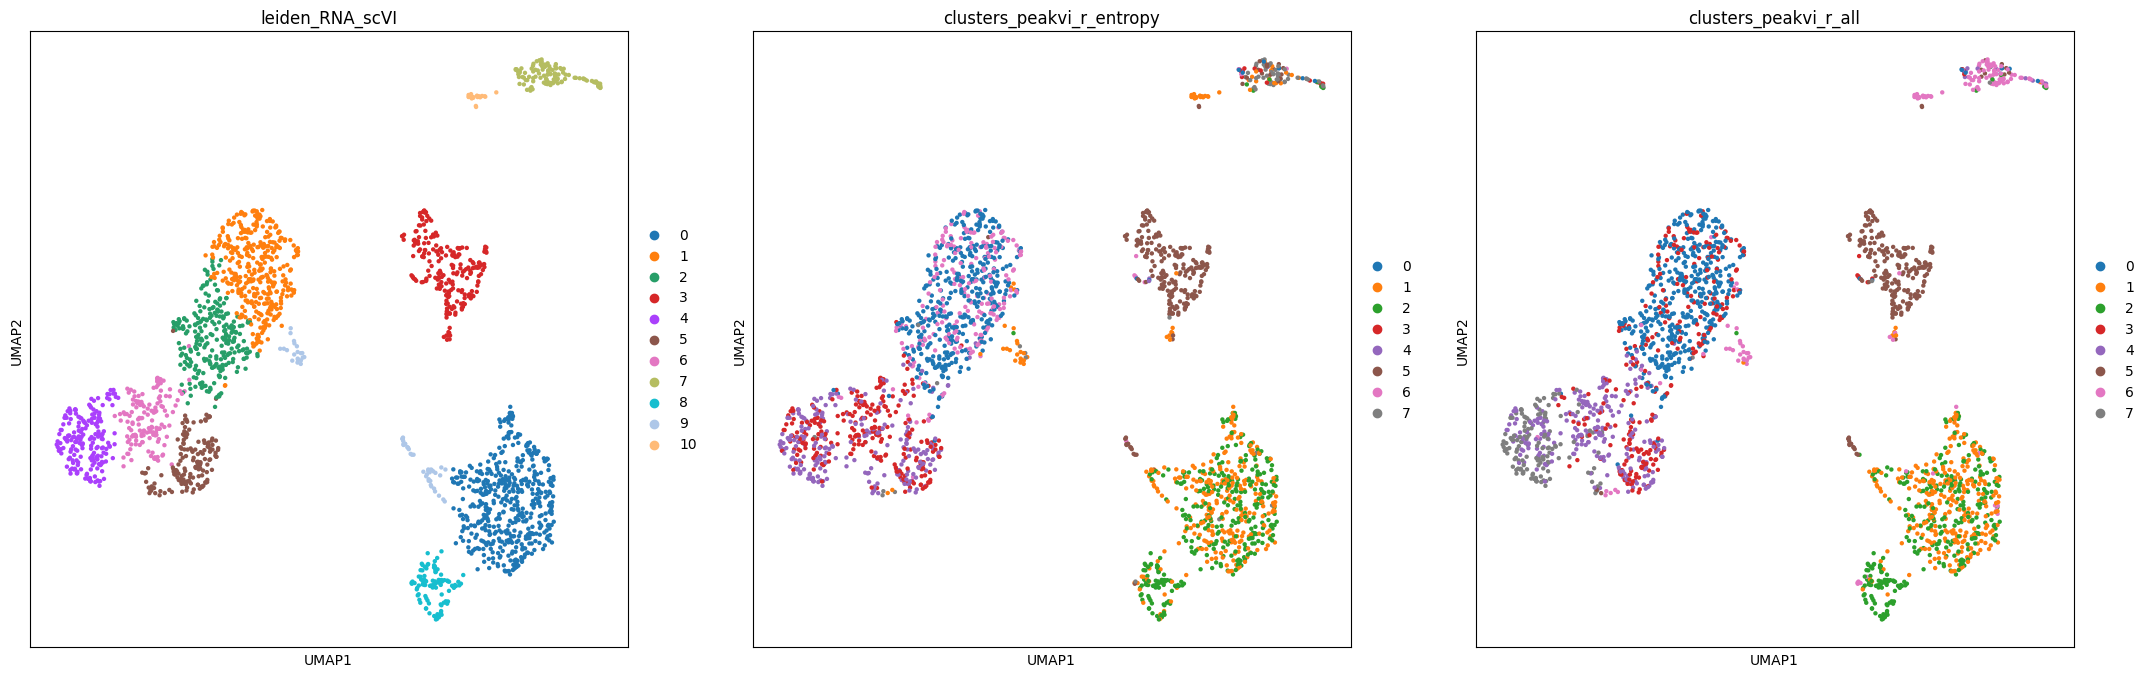

In [163]:
with plt.rc_context({'figure.figsize': (8, 8)}):
    sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'clusters_peakvi_r_entropy', 'clusters_peakvi_r_all'], wspace=0.1, ncols=3, size=40)

### match cluster by majority 

In [164]:
relate_labels = peak_df.join(entropy_peak_df['clusters_peakvi_r_entropy']).groupby(['clusters_peakvi_r_all', 'clusters_peakvi_r_entropy']).size().unstack(fill_value=0)

relate_labels = relate_labels.to_numpy()

ordered_col, remained_col = order_m(relate_labels)

relate_labels[:, ordered_col + remained_col]

/tmp/ipykernel_4095703/3076325161.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  relate_labels = peak_df.join(entropy_peak_df['clusters_peakvi_r_entropy']).groupby(['clusters_peakvi_r_all', 'clusters_peakvi_r_entropy']).size().unstack(fill_value=0)


array([[403,   0,   0,  56,   3,   0,   1,   0],
       [  0, 263,  39,   0,   0,   2,   0,   0],
       [  0,  11, 287,   0,   0,   1,   2,   0],
       [  0,   0,   0, 159,   2,   0,   0, 102],
       [ 11,   0,   0,   0, 242,   1,   1,   6],
       [  0,   1,   0,   1,   0, 221,   3,   2],
       [  2,  72,   3,   0,   2,  15,  62,   0],
       [  0,   0,   0,   0,  12,   0,   0, 137]])

In [165]:
# # Now manually map the best matching clusters
cluster_map = {str(i):str(j) for i, j in zip(list(range(relate_labels.shape[1])), ordered_col+remained_col)}
cluster_map
#entropy_peak.obs['clusters_peakvi_reorder_entropy'] = entropy_peak.obs['clusters_peakvi_r_entropy'].map(cluster_map)

entropy_peak.obs['clusters_peakvi_reorder_entropy'] = entropy_peak.obs['clusters_peakvi_r_entropy'].cat.reorder_categories([str(i) for i in ordered_col+remained_col], ordered=False)
# sc.pl.umap(entropy_peak, color='clusters_peakvi_reorder_entropy')

In [166]:
if 'clusters_peakvi_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_entropy', axis=1, inplace=True)
if 'clusters_peakvi_reorder_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_reorder_entropy', axis=1, inplace=True)

if 'clusters_peakvi_all' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_all', axis=1, inplace=True)
if 'clusters_peakvi_r_all' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_r_all', axis=1, inplace=True)
    

h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[['clusters_peakvi_entropy', 'clusters_peakvi_reorder_entropy']], left_on='atac_bc', right_index=True, how='left')
# h5_rna.obs.rename(columns={'clusters_peakvi':'clusters_peakvi_entropy'}, inplace=True)
h5_rna.obs = h5_rna.obs.merge(peak.obs[['clusters_peakvi_all', 'clusters_peakvi_r_all']], left_on='atac_bc', right_index=True, how='left')

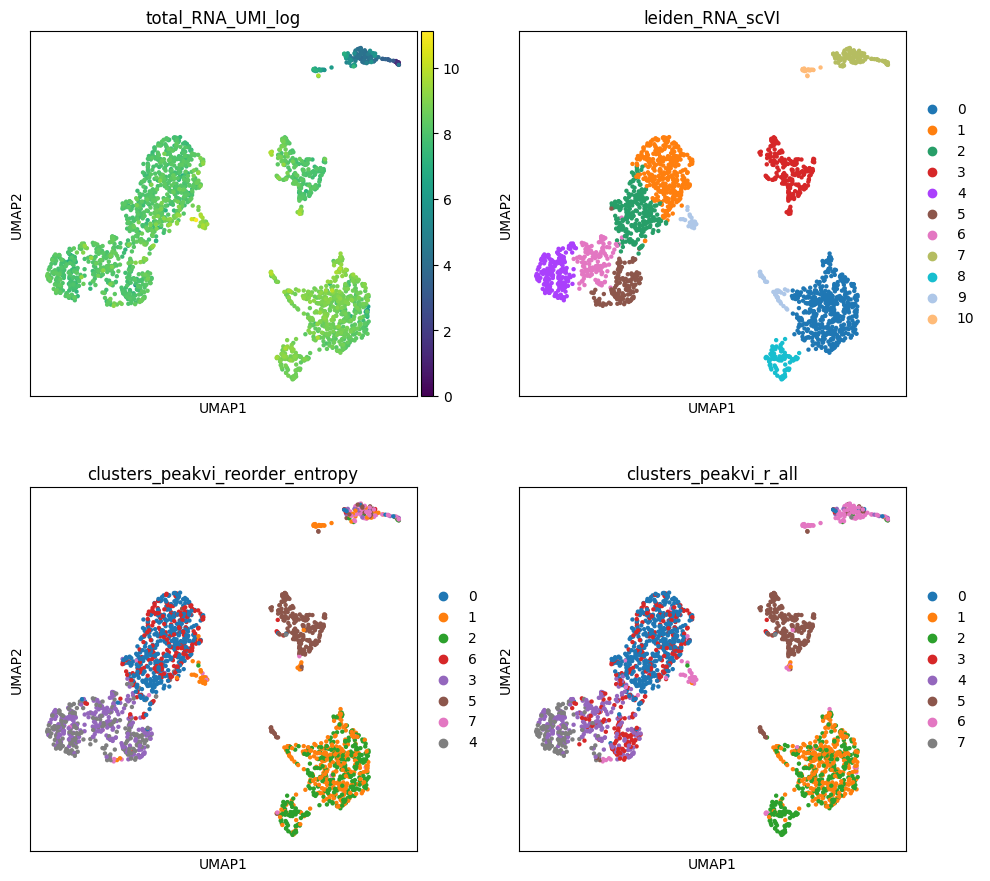

In [177]:
with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(h5_rna, color=['total_RNA_UMI_log', 'leiden_RNA_scVI', 'clusters_peakvi_reorder_entropy', 'clusters_peakvi_r_all'], wspace=0.15, ncols=2, size=40)

### On finer resolution

In [168]:
relate_labels2 = peak_df.join(entropy_peak_df['clusters_peakvi_entropy']).groupby(['clusters_peakvi_all', 'clusters_peakvi_entropy']).size().unstack(fill_value=0)

relate_labels2 = relate_labels2.to_numpy()

ordered_col, remained_col = order_m(relate_labels2)

relate_labels2[:, ordered_col + remained_col]

# # Now manually map the best matching clusters
entropy_peak.obs['clusters_peakvi_entropy2'] = entropy_peak.obs['clusters_peakvi_entropy'].cat.reorder_categories([str(i) for i in ordered_col+remained_col], ordered=False)



relate_labels2[:, ordered_col + remained_col]

/tmp/ipykernel_4095703/2550887085.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  relate_labels2 = peak_df.join(entropy_peak_df['clusters_peakvi_entropy']).groupby(['clusters_peakvi_all', 'clusters_peakvi_entropy']).size().unstack(fill_value=0)


array([[306,   0,   3,   0,  13,   0,   0,   0,   0,   1,   0,   0,  76],
       [  0, 278,   0,   0,   0,   0,   0,   0,   0,   2,   1,  18,   0],
       [  0,   0, 243,   0,   0,   1,   2,   4,   0,   1,   0,   0,  13],
       [  0,   8,   0, 126,   0,   0,   0,   0,   0,   0,   2, 124,   0],
       [ 10,   0,   0,   0, 178,   0,   0,   1,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   1, 141,   0,   0,   0,   1,  40,   0,   0],
       [  0,   0,  12,   0,   0,   0, 108,  31,   0,   0,   0,   0,   0],
       [  1,   0,   2,   0,  20,   0,   0,  99,   0,   0,   0,   0,   4],
       [  0,   0,   0,  47,   7,   0,   0,   0,  55,   1,   0,   0,   0],
       [  1,   5,   2,   0,   0,  10,   0,   0,  14,  62,   3,   1,   1],
       [  0,   0,   0,   0,   0,   1,   2,   0,   1,   2,  39,   0,   0]])

In [169]:
if 'clusters_peakvi_r_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_r_entropy', axis=1, inplace=True)
if 'clusters_peakvi_entropy2' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_entropy2', axis=1, inplace=True)

if 'clusters_peakvi_all' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_all', axis=1, inplace=True)
if 'clusters_peakvi_r_all' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_r_all', axis=1, inplace=True)
    

h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[['clusters_peakvi_r_entropy', 'clusters_peakvi_entropy2']], left_on='atac_bc', right_index=True, how='left')
# h5_rna.obs.rename(columns={'clusters_peakvi':'clusters_peakvi_entropy'}, inplace=True)
h5_rna.obs = h5_rna.obs.merge(peak.obs[['clusters_peakvi_all', 'clusters_peakvi_r_all']], left_on='atac_bc', right_index=True, how='left')

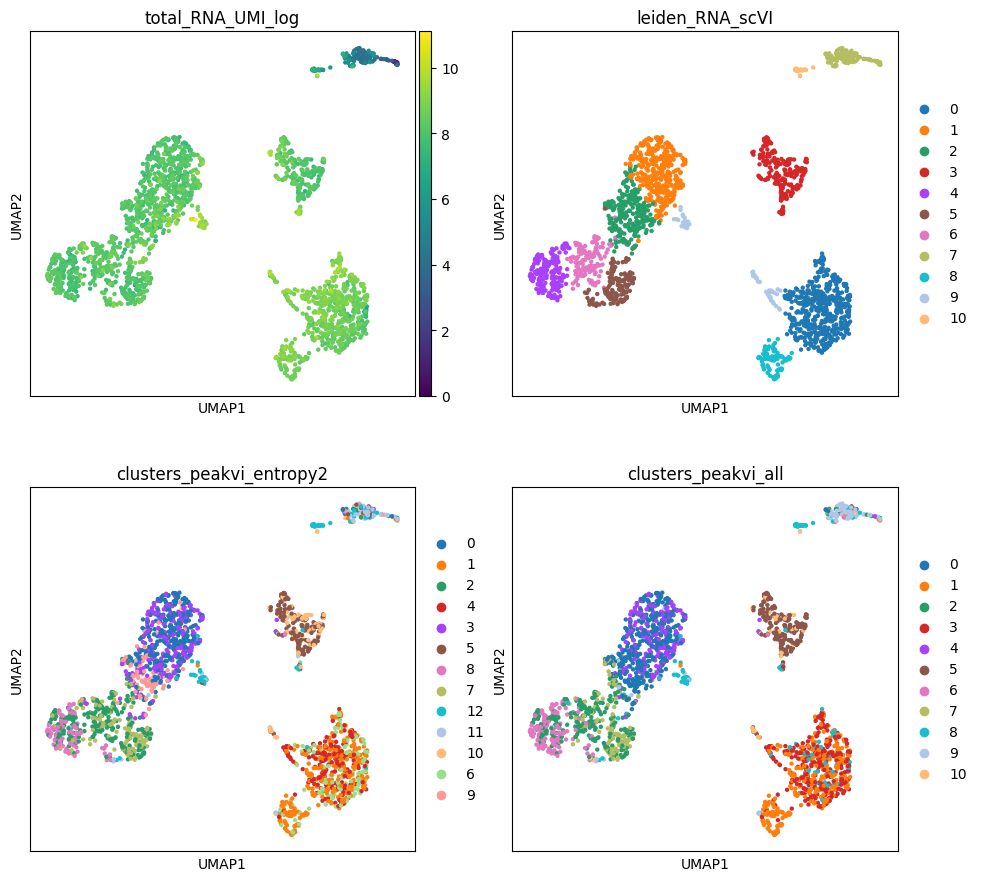

In [170]:
with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(h5_rna, color=['total_RNA_UMI_log', 'leiden_RNA_scVI', 'clusters_peakvi_entropy2', 'clusters_peakvi_all'], wspace=0.14, ncols=2, size=40)

In [171]:
(h5_rna.obs['MT%'] < 20).sum(), h5_rna.shape[0]

(2061, 2125)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


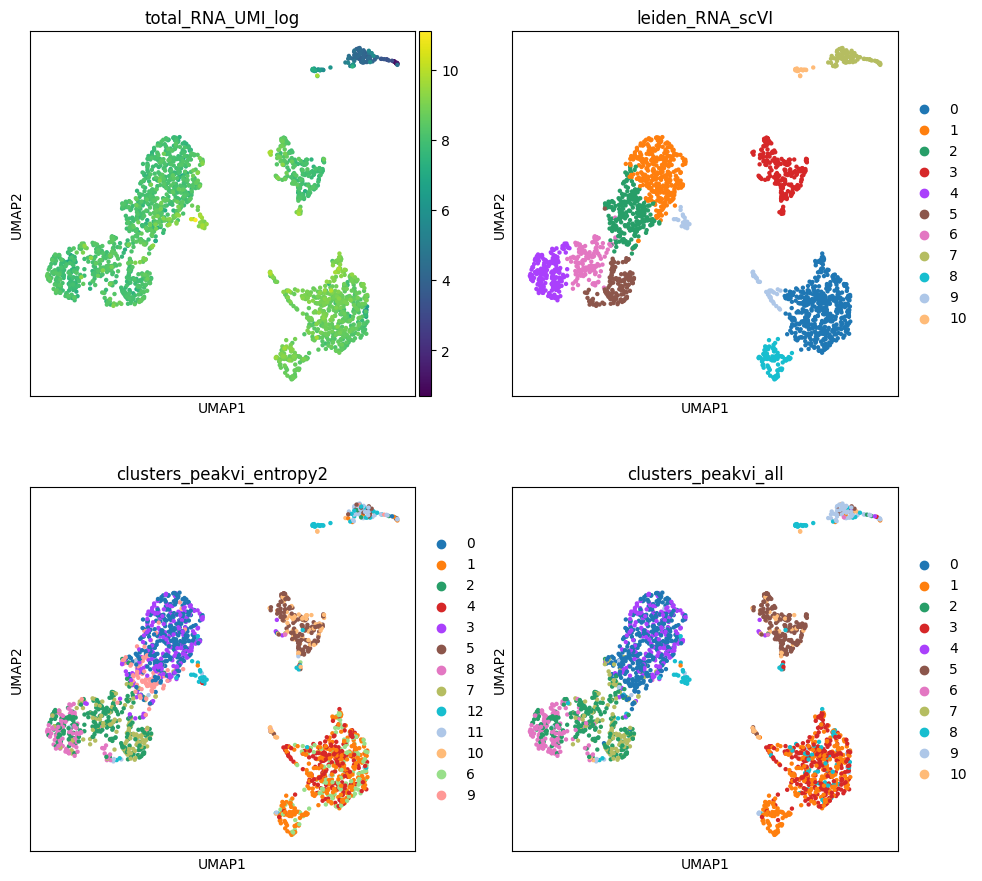

In [172]:
with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(h5_rna[h5_rna.obs['MT%'] < 20], color=['total_RNA_UMI_log', 'leiden_RNA_scVI', 'clusters_peakvi_entropy2', 'clusters_peakvi_all'], wspace=0.14, ncols=2, size=40)

## Umap on ATAC space 

In [173]:
if 'leiden_RNA_scVI' in entropy_peak.obs.columns:
    entropy_peak.obs.drop('leiden_RNA_scVI', axis=1, inplace=True)
if 'leiden_RNA_scVI' in peak.obs.columns:
    peak.obs.drop('leiden_RNA_scVI', axis=1, inplace=True)
    
entropy_peak.obs = entropy_peak.obs.merge(h5_rna.obs[['leiden_RNA_scVI']], left_on='rna_barcodes', right_index=True, how='left')
peak.obs = peak.obs.merge(h5_rna.obs[['leiden_RNA_scVI']], left_on='rna_barcodes', right_index=True, how='left')

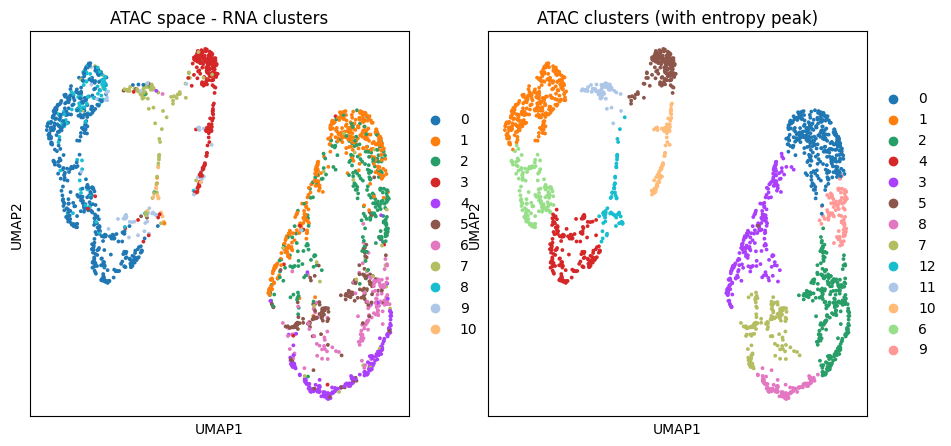

In [174]:
with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(entropy_peak, color=['leiden_RNA_scVI', 'clusters_peakvi_entropy2'], wspace=0.1,title=['ATAC space - RNA clusters', 'ATAC clusters (with entropy peak)'], size=30)

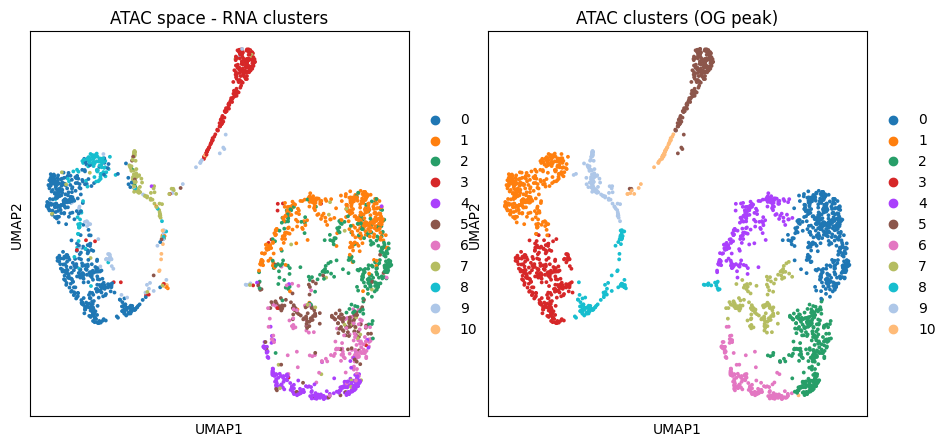

In [175]:
with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(peak, color=['leiden_RNA_scVI', 'clusters_peakvi_all'], wspace=0.1, title=['ATAC space - RNA clusters', 'ATAC clusters (OG peak)'], size=30)

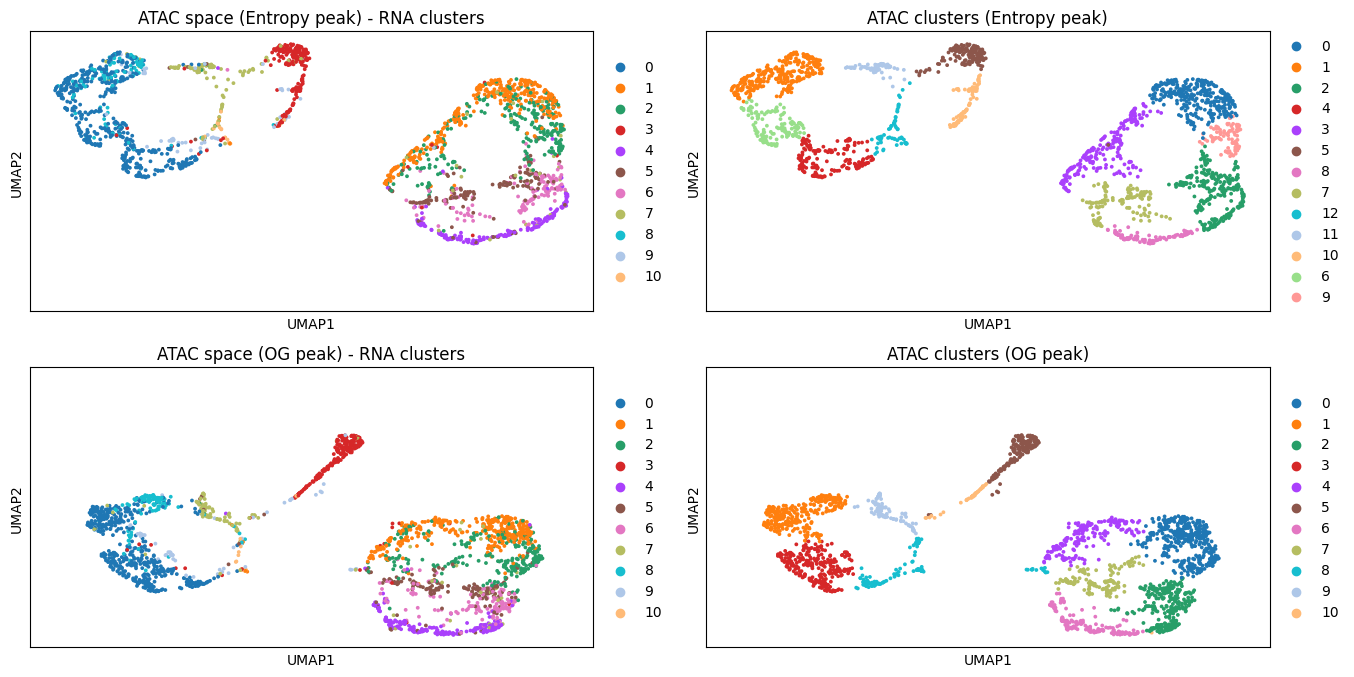

In [176]:
fig, ax = plt.subplots(2, 2, figsize=(16,8), sharex=True, sharey=True)
ax = ax.flatten()
sc.pl.umap(entropy_peak, color=['leiden_RNA_scVI'], title='ATAC space (Entropy peak) - RNA clusters', size=30, ax=ax[0], show=False)
sc.pl.umap(entropy_peak, color=['clusters_peakvi_entropy2'], title='ATAC clusters (Entropy peak)', size=30, ax=ax[1], show=False)
sc.pl.umap(peak, color=['leiden_RNA_scVI'], title='ATAC space (OG peak) - RNA clusters', size=30, ax=ax[2], show=False)
sc.pl.umap(peak, color=['clusters_peakvi_all'], title='ATAC clusters (OG peak)', size=30, ax=ax[3], show=True)

fig.tight_layout()